In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [62]:
df = pd.read_csv(r"C:\Users\mr.shoaib\Downloads\f.csv")

In [63]:
df.head(5)

,area,Year,Rooms,Location,Price,Floor
0,87,1400,2,Marzdaran,1.392000e+10,7.0
1,98,1397,2,Kooy-e Ferdows,1.060000e+10,5.0
2,60,1396,1,Ebrahimabad,1.560000e+10,1.0
3,87,1394,2,Plan & Budget Organization,9.500000e+09,3.0
4,170,1375,3,Formaneya,3.400000e+11,2.0


In [116]:
df = df.drop(['Location'],axis=1)

In [117]:
df.isnull().sum()

area     0
Year     0
Rooms    0
Price    0
Floor    0
dtype: int64

In [118]:
df['Price'].fillna(df['Price'].mean(),inplace=True)
df['Floor'].fillna(df['Floor'].median(),inplace=True)

In [119]:
df

,area,Year,Rooms,Price,Floor
0,87,1400,2,1.392000e+10,7.0
1,98,1397,2,1.060000e+10,5.0
2,60,1396,1,1.560000e+10,1.0
3,87,1394,2,9.500000e+09,3.0
4,170,1375,3,3.400000e+11,2.0
...,...,...,...,...,...
831,133,1381,3,1.060000e+09,5.0
832,89,1400,2,2.403000e+10,2.0
833,75,1399,2,7.600000e+07,1.0
834,50,1391,1,1.500000e+08,2.0


In [120]:
df.isnull().sum()

area     0
Year     0
Rooms    0
Price    0
Floor    0
dtype: int64

In [121]:
x = df.iloc[:,:-1]
y = df["Floor"]

In [122]:
x

,area,Year,Rooms,Price
0,87,1400,2,1.392000e+10
1,98,1397,2,1.060000e+10
2,60,1396,1,1.560000e+10
3,87,1394,2,9.500000e+09
4,170,1375,3,3.400000e+11
...,...,...,...,...
831,133,1381,3,1.060000e+09
832,89,1400,2,2.403000e+10
833,75,1399,2,7.600000e+07
834,50,1391,1,1.500000e+08


In [123]:
y

0      7.0
1      5.0
2      1.0
3      3.0
4      2.0
      ... 
831    5.0
832    2.0
833    1.0
834    2.0
835    9.0
Name: Floor, Length: 836, dtype: float64

In [124]:
sc = StandardScaler()
sc.fit(x)
sc.transform(x)

array([[-0.41343075,  0.81014694, -0.21284719, -0.0697991 ],
       [-0.26308635,  0.43297068, -0.21284719, -0.0728529 ],
       [-0.78245792,  0.30724526, -1.53092315, -0.0682538 ],
       ...,
       [-0.57744283,  0.68442152, -0.21284719, -0.08253308],
       [-0.91913465, -0.32138185, -1.53092315, -0.08246501],
       [-0.4407661 , -0.82428353, -0.21284719, -0.08111288]])

In [125]:
x_train,x_test,y_train,y_train = train_test_split(x,y,test_size=0.2,random_state=42)

In [126]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge

In [127]:
lr = LinearRegression()   #ye object hai.
lr.fit(x,y)

LinearRegression()

In [128]:
lr.score(x,y)*100

12.980285382911827

In [129]:
lr.coef_

array([ 3.95779332e-03,  1.49502361e-01,  7.08129237e-01, -6.36248346e-14])

In [130]:
lr.intercept_

-206.5166857375146

In [131]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [132]:
mean_squared_error(y,lr.predict(x))

15.765053120938868

In [133]:
mean_absolute_error(y,lr.predict(x))

2.466072386460868

In [134]:
y_pred = lr.predict(x)

In [135]:
r2_score(y, y_pred)*100

12.980285382911827

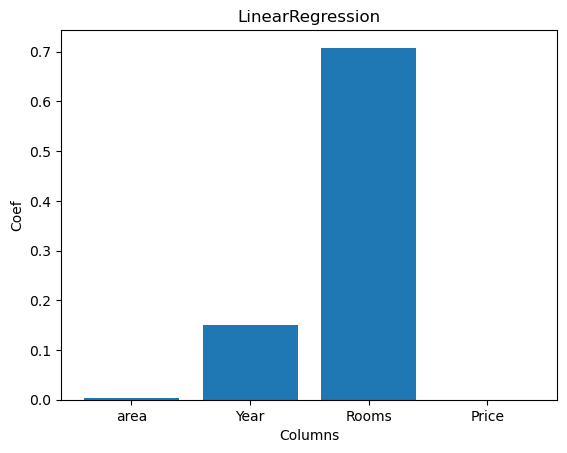

In [136]:
#Linear Regression.
plt.bar(x.columns,lr.coef_)
plt.title("LinearRegression")
plt.xlabel("Columns")
plt.ylabel("Coef")
plt.show()

Lasso

In [137]:
la =  Lasso(alpha=2)
la.fit(x,y)

Lasso(alpha=2)

In [138]:
la.score(x,y)*100

11.869724783071856

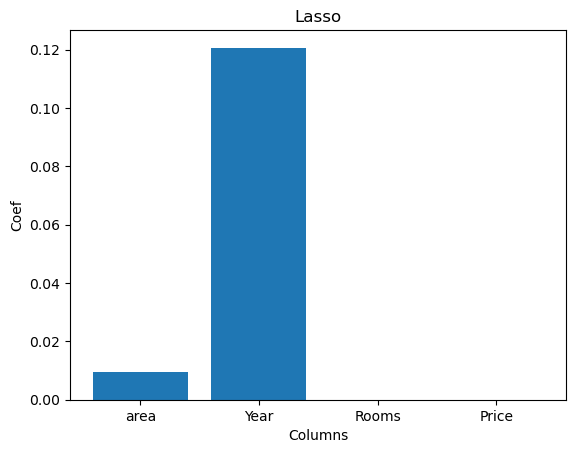

In [139]:
plt.bar(x.columns,la.coef_)
plt.title("Lasso")
plt.xlabel("Columns")
plt.ylabel("Coef")
plt.show()

Ridge

In [140]:
ri = Ridge(alpha=10)
ri.fit(x,y)

Ridge(alpha=10)

In [141]:
ri.score(x,y)*100

12.97896164535376

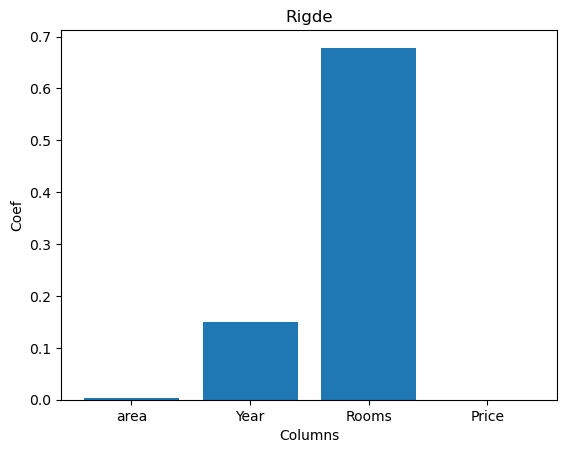

In [142]:
plt.bar(x.columns,ri.coef_)
plt.title("Rigde")
plt.xlabel("Columns")
plt.ylabel("Coef")
plt.show()